# Partisjonsfunksjonen og molekylær energi

:::{admonition} Læringsmål
:class: note

Etter å ha arbeidet med dette kapitlet skal du kunne:

- forklare hva et statistisk ensemble er
- forklare hva partisjonsfunksjonen forteller oss
- sette opp og beregne partisjonsfunksjonen for enkle systemer med bestemte energinivåer
- forklare Gibbs-entropien for en generell sannsynlighetsfordeling
- vise at Gibbs-entropien gir $S=k_\mathrm{B}\ln\Omega$ når mikrotilstandene er like sannsynlige
- forklare hvordan $U$, $S$ og $C_V$ kan beregnes fra partisjonsfunksjonen
:::

:::{admonition} Kapitlet i et nøtteskall
:class: note

Energiene forteller hvilke mikrotilstander systemet kan ha. Temperaturen bestemmer hvor stor Boltzmann-vekt hver mikrotilstand får. Partisjonsfunksjonen $Q$ er summen av disse vektene. Når vi deler hver vekt på $Q$, får vi sannsynlighetene. Den samme partisjonsfunksjonen kan deretter brukes til å beregne indre energi, entropi og varmekapasitet.

:::

I [forrige kapittel](2_entropi_boltzmann.html) kom vi fram til Boltzmann-fordelingen

$$p_i=\frac{1}{Q}e^{-E_i/k_\mathrm{B}T}$$

Fordelingen sier at én bestemt mikrotilstand med lav energi vanligvis er mer sannsynlig enn én bestemt mikrotilstand med høy energi. Figuren nedenfor viser en enkel modell med elleve jevnt fordelte energinivåer. Hvert nivå svarer til én mikrotilstand. Mikrotilstanden med energi $E=0$ har størst sannsynlighet. Temperaturen bestemmer hvor raskt sannsynligheten avtar når energien øker.

Ved lav temperatur er $k_\mathrm{B}T$ liten sammenliknet med avstanden mellom energinivåene. Da er systemet nesten alltid i den laveste mikrotilstanden. Ved høy temperatur blir forskjellen mellom sannsynlighetene mindre. Mikrotilstander med energiforskjeller som er mye mindre enn $k_\mathrm{B}T$, blir omtrent like sannsynlige. Mikrotilstander som ligger mye høyere i energi, er fortsatt lite sannsynlige.


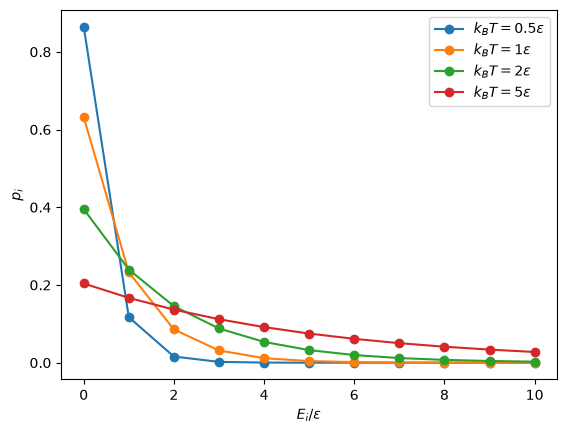

In [2]:
import numpy as np
import matplotlib.pyplot as plt

i = np.arange(0, 11)      # kvantetall
E = i                     # energi i enheter av epsilon

for kT in [0.5, 1, 2, 5]:
    weights = np.exp(-E/kT)
    Q = weights.sum()
    p = weights/Q
    plt.plot(E, p, "o-", label=f"$k_BT = {kT}\\varepsilon$")

plt.xlabel(r"$E_i / \varepsilon$")
plt.ylabel(r"$p_i$")
plt.legend()
plt.show()

Når vi bare sammenlikner to mikrotilstander, faller $Q$ bort

$$\frac{p_2}{p_1}=e^{-(E_2-E_1)/k_\mathrm{B}T}$$

Vi trenger derfor ikke $Q$ for å finne forholdet mellom to sannsynligheter. Skal vi finne selve sannsynlighetene, trenger vi derimot $Q$.

Partisjonsfunksjonen har to viktige oppgaver. Først gjør den Boltzmann-vektene om til sannsynligheter som summerer til 1. I tillegg samler den informasjon om energinivåene og temperaturen. Når vi kjenner $Q$, kan vi derfor beregne flere målbare egenskaper uten å følge hver enkelt mikrotilstand i detalj.


(nar-gjelder-boltzmann-fordelingen)=
## Når gjelder Boltzmann-fordelingen?

Boltzmann-fordelingen beskriver et system som er i termisk likevekt med omgivelsene. Systemet kan ta opp og avgi energi, men omgivelsene er så store at temperaturen deres praktisk talt ikke endres. Slike omgivelser kalles et **varmereservoar**.

Vi bruker følgende modell:

- partikkeltallet $N$ er fast
- volumet $V$ er fast
- temperaturen $T$ er fast
- energien $E_i$ kan variere når systemet skifter mikrotilstand

Ved termisk likevekt er sannsynligheten for mikrotilstand $i$

$$p_i=\frac{e^{-E_i/k_\mathrm{B}T}}{Q}$$

Systemets energi varierer fra mikrotilstand til mikrotilstand. Gjennomsnittsenergien er likevel stabil

$$U=\langle E\rangle$$

:::{admonition} Hva betyr $\langle E\rangle$?
:class: note

De spisse parentesene betyr at vi tar gjennomsnittet, eller forventningsverdien, av energien. Du kan lese mer om dette i [6.2 Forventningsverdi](matematikk/statistikk.html#forventningsverdi).

:::

### Det kanoniske ensemblet

Ordet **ensemble** kan høres mer komplisert ut enn ideen er. Et ensemble er en modell som sier hvilke størrelser vi holder faste, og hvilke som kan variere. Du kan lese mer i [grunnleggende begreper](A1_grunnleggende_begreper.html#ensembler).

Når $N$, $V$ og $T$ er faste, mens energien kan variere, bruker vi det **kanoniske ensemblet**.

For å regne på systemet kan vi forestille oss mange identiske kopier av det. Alle kopiene har samme $N$, $V$ og $T$, men de kan være i forskjellige mikrotilstander. Hvis 20 prosent av kopiene er i mikrotilstand $i$, er sannsynligheten for denne mikrotilstanden $p_i=0{,}20$.

Kopiene er bare et tanke- og regneverktøy. De gjør det lettere å forstå hva en sannsynlighet og et gjennomsnitt betyr.

:::{admonition} Fra isolert til kanonisk
:class: note

I et isolert system er $N$, $V$ og den totale energien faste. Dette kalles det **mikrokanoniske ensemblet**.

I det kanoniske ensemblet kan systemet utveksle energi med et varmereservoar. Da er $N$, $V$ og $T$ faste, mens energien kan variere.

Det er denne situasjonen vi bruker når vi arbeider med Boltzmann-fordelingen i dette kapitlet.

:::

:::{dropdown} Fordypning: gir ulike ensembler ulike svar?

Ulike ensembler beskriver ulike fysiske betingelser og har derfor ulike sannsynlighetsfordelinger og partisjonsfunksjoner. For svært store systemer gir de vanligvis de samme likevektsresultatene når de beskriver den samme fysiske tilstanden.

:::

:::{admonition} Underveisoppgave
:class: tip

En lukket gassbeholder med fast volum står i et stort vannbad med konstant temperatur.

1. Hvilke av størrelsene $N$, $V$ og $T$ holdes faste?
2. Kan energien til systemet variere?
3. Hvorfor kan energien variere selv om temperaturen er konstant?
4. Hvilket ensemble beskriver denne situasjonen?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

$N$, $V$ og $T$ holdes faste. Systemet kan utveksle energi med vannbadet og derfor skifte mellom mikrotilstander med forskjellig energi. Temperaturen er stabil fordi vannbadet er mye større enn systemet. Situasjonen beskrives av det kanoniske ensemblet.

:::

Simuleringen nedenfor viser den tenkte samlingen av identiske kopier. Den gjør det mulig å undersøke hvordan et ensemblegjennomsnitt blir mer stabilt når antallet kopier øker.


In [ ]:
from IPython.display import HTML

with open("Simuleringer/ensemblegjennomsnitt.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

Hver rute i simuleringen representerer én kopi av det samme systemet. I hver kopi kan noen av partiklene være i den eksiterte tilstanden. Histogrammet viser hvor mange eksiterte partikler de ulike kopiene har. Siden hver eksitasjon gir det samme energibidraget, viser histogrammet også hvordan energien varierer mellom kopiene. I denne simuleringen velger du sannsynligheten $p$ direkte. Senere bruker vi partisjonsfunksjonen til å beregne denne sannsynligheten fra energiene og temperaturen.

:::{admonition} Prøv selv: ensemblegjennomsnitt
:class: tip

1. Trekk flere ensembler med få kopier. Hvor mye varierer gjennomsnittet fra trekk til trekk?
2. Øk antallet kopier $M$. Hva skjer med variasjonen i gjennomsnittet?
3. Øk antallet partikler $N$ i hver kopi. Hva skjer med bredden på fordelingen av $n/N$?
4. Endre sannsynligheten $p$ for at en partikkel er eksitert. Hvordan flyttes gjennomsnittet?
5. Hvorfor kan kopiene ha ulike energier selv om de har samme temperatur?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Med få kopier varierer gjennomsnittet merkbart fra trekk til trekk. Når $M$ øker, nærmer gjennomsnittet seg den forventede verdien $p$. Når $N$ øker, blir fordelingen av andelen eksiterte partikler smalere. Kopiene kan ha ulike mikrotilstander og energier, mens temperaturen bestemmer den stabile sannsynlighetsfordelingen for hele ensemblet.

:::


## Partisjonsfunksjonen

For å finne sannsynlighetene må vi først summere Boltzmann-vektene til alle mikrotilstandene. Denne summen kalles **partisjonsfunksjonen**.

:::{admonition} Kanonisk partisjonsfunksjon
:class: important

$$Q=\sum_i e^{-E_i/k_\mathrm{B}T}$$

Sannsynligheten for mikrotilstand $i$ er

$$p_i=\frac{e^{-E_i/k_\mathrm{B}T}}{Q}$$

:::

Boltzmann-vektene $e^{-E_i/k_\mathrm{B}T}$ summerer ikke nødvendigvis til 1. Derfor er de ikke sannsynligheter ennå. Når vi deler hver vekt på summen $Q$, får vi sannsynligheter som til sammen er lik 1.

Partisjonsfunksjonen er altså ikke selv en sannsynlighet. Den er heller ikke generelt et bokstavelig antall mikrotilstander.

:::{admonition} Hvilket system gjelder $Q$ for?
:class: note

Energiene $E_i$ og partisjonsfunksjonen $Q$ må beskrive det samme systemet. Hvis $E_i$ er energiene til ett molekyl, gjelder sannsynlighetene og gjennomsnittsenergien dette molekylet. Hvis $E_i$ er energiene til hele prøven, gjelder $Q$, $U$ og $S$ for hele prøven.

Senere i kapitlet skal vi se hvordan vi kan kombinere partisjonsfunksjonene til flere uavhengige delsystemer.

:::

:::{admonition} Underveisoppgave
:class: tip

Et system har tre mikrotilstander med energiene $E_0=0$, $E_1=2{,}0\times10^{-21}\ \mathrm{J}$ og $E_2=4{,}0\times10^{-21}\ \mathrm{J}$. Temperaturen er $T=300\ \mathrm{K}$, og $k_\mathrm{B}=1{,}381\times10^{-23}\ \mathrm{J/K}$.

**a)** Regn ut Boltzmann-faktoren $e^{-E_i/k_\mathrm{B}T}$ for hver mikrotilstand.

**b)** Regn ut partisjonsfunksjonen $Q$.

**c)** Regn ut sannsynligheten $p_i$ for hver mikrotilstand. Kontroller at sannsynlighetene summerer til 1, og forklar hvorfor grunntilstanden er mest sannsynlig.

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Først beregner vi den termiske energiskalaen

$$k_\mathrm{B}T=1{,}381\times10^{-23}\cdot300=4{,}14\times10^{-21}\ \mathrm{J}$$

**a)** Boltzmann-faktorene blir

$$e^{-E_0/k_\mathrm{B}T}=1{,}000$$

$$e^{-E_1/k_\mathrm{B}T}=e^{-2{,}0/4{,}14}=0{,}617$$

$$e^{-E_2/k_\mathrm{B}T}=e^{-4{,}0/4{,}14}=0{,}381$$

**b)** Partisjonsfunksjonen er summen av vektene

$$Q=1{,}000+0{,}617+0{,}381=1{,}998$$

**c)** Sannsynlighetene er vektene delt på $Q$

$$p_0=0{,}500\qquad p_1=0{,}309\qquad p_2=0{,}191$$

Summen er 1, som den må være fordi systemet befinner seg i én av de tre mikrotilstandene. Grunntilstanden er den mest sannsynlige enkeltmikrotilstanden fordi den har lavest energi og størst Boltzmann-faktor. Et helt energinivå med høyere energi kan likevel få stor samlet sannsynlighet dersom nivået består av mange mikrotilstander.

:::

### Når flere mikrotilstander har samme energi

Som vi så i [introduksjonskapitlet](A1_grunnleggende_begreper.html#energitilstander-og-frihetsgrader), kan flere mikrotilstander ha samme energi. Da sier vi at energinivået er **degenerert**.

Hvis et energinivå med energi $E_j$ består av $g_j$ mikrotilstander, kalles $g_j$ degenerasjonen til nivået. Alle de $g_j$ mikrotilstandene har samme Boltzmann-vekt

$$e^{-E_j/k_\mathrm{B}T}$$

Det samlede bidraget fra energinivået blir derfor

$$g_j e^{-E_j/k_\mathrm{B}T}$$

Vi kan dermed summere over energinivåene i stedet for å skrive ett ledd for hver mikrotilstand

$$Q=\sum_j g_j e^{-E_j/k_\mathrm{B}T}$$

I den første formelen løper indeksen $i$ over mikrotilstandene. I den siste formelen løper $j$ over energinivåene.

Energi og degenerasjon trekker i hver sin retning. Høy energi gir mindre Boltzmann-vekt. Stor degenerasjon betyr at mange mikrotilstander bidrar med den samme vekten. Først undersøker vi energigapet i en modell uten degenerasjon. Deretter bruker vi en enkel molekylmodell til å se hvordan degenerasjon påvirker den samlede sannsynligheten.


In [1]:
from IPython.display import HTML

with open("Simuleringer/tilgjengelig_vs_effektivt_tilgjengelig_v3.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

:::{admonition} Prøv selv: hva forteller $Q$?
:class: tip

1. Gjør energigapet stort sammenliknet med $k_\mathrm{B}T$. Hvilke energinivåer bidrar merkbart til $Q$?
2. Gjør energigapet mindre. Hva skjer med Boltzmann-vektene og $Q$?
3. Endres antallet tillatte energinivåer når temperaturen endres?
4. Hvorfor kan $Q$ øke selv om antallet energinivåer er uendret?
5. Hva er forskjellen på en Boltzmann-vekt og en sannsynlighet?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Ved stort energigap bidrar hovedsakelig grunntilstanden. Når gapet blir mindre sammenliknet med $k_\mathrm{B}T$, får de eksiterte nivåene større vekt, og $Q$ øker. Temperaturen endrer ikke hvilke energinivåer som finnes. Den endrer bare vektene deres. En Boltzmann-vekt blir først en sannsynlighet når vi deler den på summen $Q$.

:::


:::{card}

**Eksempel: en idealisert molekylbryter**
^^^

Tenk deg en enkel modell av et molekyl som kan være lukket eller åpent. Den lukkede tilstanden har energi $0$ og består av én mikrotilstand. Det åpne energinivået ligger $\Delta\varepsilon$ høyere i energi og består av tre mikrotilstander med samme energi.

Partisjonsfunksjonen for ett molekyl er

$$Q_1=1+3e^{-\Delta\varepsilon/k_\mathrm{B}T}$$

Indeksen 1 minner om at dette er partisjonsfunksjonen til ett enkelt molekyl. I avsnittet [Fra ett delsystem til mange](#fra-ett-delsystem-til-mange) ser vi hvordan slike settes sammen til en partisjonsfunksjon $Q_N$ for hele systemet. Sannsynligheten for det lukkede energinivået er

$$p_\mathrm{lukket}=\frac{1}{Q_1}$$

Den samlede sannsynligheten for det åpne energinivået er

$$p_\mathrm{åpen}=\frac{3e^{-\Delta\varepsilon/k_\mathrm{B}T}}{Q_1}$$

Ved lav temperatur dominerer den lukkede tilstanden fordi den har lavest energi. Ved høy temperatur blir de fire mikrotilstandene omtrent like sannsynlige. Da går den samlede sannsynligheten for det åpne nivået mot $3/4$, mens sannsynligheten for den lukkede tilstanden går mot $1/4$.

Eksemplet viser hvordan energi og degenerasjon konkurrerer. Den åpne tilstanden har høyere energi, men den kan realiseres gjennom flere mikrotilstander.

![Sannsynligheten for lukket og åpen tilstand som funksjon av $k_\mathrm{B}T/\Delta\varepsilon$](Simuleringer/molekylbryter_populasjon.png)

:::

:::{admonition} Underveisoppgave
:class: tip

1. Når er den åpne og den lukkede tilstanden like sannsynlige?
2. Hvorfor går ikke sannsynligheten for den lukkede tilstanden mot null ved høy temperatur?
3. Hva blir høytemperaturgrensen dersom det åpne nivået har degenerasjon $g=5$?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

De to nivåene er like sannsynlige når

$$3e^{-\Delta\varepsilon/k_\mathrm{B}T}=1$$

Den lukkede tilstanden er fortsatt én av de fire mulige mikrotilstandene og får derfor sannsynligheten $1/4$ ved høy temperatur. Med $g=5$ går den samlede sannsynligheten for det åpne nivået mot $5/6$, mens sannsynligheten for det lukkede nivået går mot $1/6$.

:::


## Indre energi fra partisjonsfunksjonen

Så langt har vi brukt partisjonsfunksjonen til å finne sannsynlighetene for mikrotilstandene. Den samme partisjonsfunksjonen kan også brukes til å beregne målbare størrelser. Vi begynner med den indre energien.

Systemet skifter stadig mellom mikrotilstander med forskjellige energier. Den indre energien $U$ er derfor ikke energien til én bestemt mikrotilstand. Den er gjennomsnittet av energiene til alle mikrotilstandene.

Mikrotilstander med stor sannsynlighet skal bidra mer til gjennomsnittet enn mikrotilstander med liten sannsynlighet. Derfor ganger vi hver energi $E_i$ med sannsynligheten $p_i$

$$U=\langle E\rangle=\sum_i p_iE_i$$

Energiene, sannsynlighetene og partisjonsfunksjonen må beskrive det samme systemet. Symbolet $\langle E\rangle$ betyr gjennomsnittsverdien av energien. Du kan lese mer i [6.2 Forventningsverdi](matematikk/statistikk.html#forventningsverdi).

Setter vi inn Boltzmann-fordelingen

$$p_i=\frac{e^{-E_i/k_\mathrm{B}T}}{Q}$$

får vi

$$U=\frac{1}{Q}\sum_i E_i e^{-E_i/k_\mathrm{B}T}$$

Dette uttrykket kan brukes direkte. Det finnes også en annen nyttig måte å finne $U$ på. Partisjonsfunksjonen endres med temperaturen, og denne endringen forteller hvordan gjennomsnittsenergien endres.

Når energinivåene ikke selv avhenger av temperaturen, får vi

:::{admonition} Indre energi fra $Q$
:class: important

$$U=k_\mathrm{B}T^2\left(\frac{\partial\ln Q}{\partial T}\right)_{V,N}$$

:::

Den [deriverte](matematikk/kalkulus.html#definisjonen-av-den-deriverte) beskriver hvordan $\ln Q$ endres når temperaturen endres, mens volumet og partikkeltallet holdes faste. Du trenger ikke følge utledningen for å forstå resten av kapitlet.

:::{dropdown} Hvor kommer uttrykket for $U$ fra?

Vi starter med partisjonsfunksjonen

$$Q=\sum_i e^{-E_i/k_\mathrm{B}T}$$

Når energiene $E_i$ ikke avhenger av $T$, får vi ved derivasjon

$$\frac{\partial Q}{\partial T}=\sum_i \frac{E_i}{k_\mathrm{B}T^2}e^{-E_i/k_\mathrm{B}T}$$

Vi trekker faktoren $1/(k_\mathrm{B}T^2)$ utenfor summen

$$\frac{\partial Q}{\partial T}=\frac{1}{k_\mathrm{B}T^2}\sum_i E_i e^{-E_i/k_\mathrm{B}T}$$

Fra uttrykket for den indre energien har vi

$$U=\frac{1}{Q}\sum_i E_i e^{-E_i/k_\mathrm{B}T}$$

Dermed kan vi skrive

$$U=\frac{k_\mathrm{B}T^2}{Q}\frac{\partial Q}{\partial T}$$

Siden

$$\frac{\partial\ln Q}{\partial T}=\frac{1}{Q}\frac{\partial Q}{\partial T}$$

får vi

$$U=k_\mathrm{B}T^2\left(\frac{\partial\ln Q}{\partial T}\right)_{V,N}$$

:::

Simuleringen nedenfor viser hvordan sannsynlighetene bestemmer plasseringen av gjennomsnittsenergien $U$. Den viser også hvordan varmekapasiteten endres når energifordelingen endres.


In [ ]:
from IPython.display import HTML

with open("Simuleringer/indre_energi_ensemble_gjennomsnitt.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

:::{admonition} Prøv selv: indre energi og varmekapasitet
:class: tip

1. Gjør $\Delta\varepsilon/k_\mathrm{B}T$ stor. Hvilken mikrotilstand dominerer, og hvor ligger $U$?
2. Gjør $\Delta\varepsilon/k_\mathrm{B}T$ mindre. Hva skjer med sannsynlighetene og $U/\Delta\varepsilon$?
3. Finn omtrent hvor $C_V/k_\mathrm{B}$ er størst. Hvorfor er varmekapasiteten liten i begge ender av glideren?
4. Hvorfor kan $U$ ligge mellom energinivåene når systemet alltid har én av de tillatte energiene?
5. Hva er forskjellen på energien til én kopi og gjennomsnittsenergien til hele ensemblet?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Når energigapet er stort sammenliknet med $k_\mathrm{B}T$, dominerer grunntilstanden, og $U$ ligger nær null. Når gapet blir mindre, øker sannsynligheten for de eksiterte nivåene. Da øker også $U/\Delta\varepsilon$.

Varmekapasiteten er størst når en temperaturendring flytter mye sannsynlighet mellom energinivåene. Ved svært lav temperatur er nesten bare grunntilstanden befolket. Ved svært høy temperatur er de fem nivåene allerede nesten likt befolket. I begge grensene endres $U$ lite når temperaturen endres, og $C_V$ blir liten.

At $C_V$ går mot null ved høy temperatur, skyldes at denne enkle modellen bare har fem energinivåer. Reelle molekyler har mange flere nivåer. Senere skal vi se at slike systemer kan nærme seg en klassisk, ikke-null verdi for varmekapasiteten.

$U$ er et gjennomsnitt og trenger ikke være en tillatt mikrotilstandsenergi. Én kopi har alltid én bestemt energi. Ensemblegjennomsnittet kan ligge mellom energinivåene.

:::

:::{dropdown} Fordypning: energifluktuasjoner og varmekapasitet

I det kanoniske ensemblet kan varmekapasiteten også skrives ved spredningen i energien

$$C_V=\frac{\langle E^2\rangle-\langle E\rangle^2}{k_\mathrm{B}T^2}$$

Uttrykket i telleren er variansen til energien. Simuleringen beregner dette uttrykket for de fem energinivåene. Varmekapasiteten blir stor når flere energier har merkbar sannsynlighet og fordelingen endres tydelig med temperaturen.

:::


## Gibbs-entropi

Boltzmanns uttrykk

$$S=k_\mathrm{B}\ln\Omega$$

gjelder direkte når de $\Omega$ mikrotilstandene er like sannsynlige. I det [kanoniske ensemblet](3_partisjonsfunksjonen.html#det-kanoniske-ensemblet) har mikrotilstander med forskjellig energi også forskjellig sannsynlighet. Da må entropien ta hensyn både til hvor mange mikrotilstander som finnes, og til hvordan sannsynligheten er fordelt mellom dem.

Gibbs-entropien gjør nettopp dette

:::{admonition} Gibbs-entropi
:class: important

$$S=-k_\mathrm{B}\sum_i p_i\ln p_i$$

Her er $p_i$ sannsynligheten for mikrotilstand $i$. Hvis $p_i=0$, bruker vi grenseverdien $0\ln0=0$.

:::

### Hva forteller uttrykket?

Gibbs-entropien er et sannsynlighetsvektet gjennomsnitt, på samme måte som uttrykket for indre energi

$$\frac{S}{k_\mathrm{B}}=\sum_i p_i(-\ln p_i)$$

Vi trenger ikke gi størrelsen $-\ln p_i$ en egen fysisk tolkning. Det viktige er hva hele summen forteller:

- Hvis nesten all sannsynlighet ligger i én mikrotilstand, er entropien lav
- Hvis sannsynligheten er fordelt over mange mikrotilstander, er entropien høyere
- For et gitt antall mikrotilstander er entropien størst når alle er like sannsynlige

Hvis én mikrotilstand har sannsynlighet 1, får vi

$$S=-k_\mathrm{B}(1\ln1)=0$$

Bare én mikrotilstand bidrar da til fordelingen. Hvis sannsynligheten i stedet er fordelt likt over mange mikrotilstander, kan langt flere mikroskopiske utfall realiseres.

:::{admonition} Underveisoppgave
:class: tip

Entropien kan skrives som

$$\frac{S}{k_\mathrm{B}}=\sum_i p_i(-\ln p_i)$$

**a)** Et system har fire like sannsynlige mikrotilstander med $p_i=1/4$. Regn ut $S/k_\mathrm{B}$.

**b)** Et annet system har fordelingen $p=(0{,}90,0{,}05,0{,}03,0{,}02)$. Regn ut $S/k_\mathrm{B}$.

**c)** Sammenlikn svarene. Hvilken fordeling har størst entropi, og hvorfor? Hva blir $S/k_\mathrm{B}$ dersom én mikrotilstand har sannsynlighet 1?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

For fire like sannsynligheter får vi

$$\frac{S}{k_\mathrm{B}}=4\cdot\frac14\left(-\ln\frac14\right)=\ln4\approx1{,}39$$

For den skjeve fordelingen får vi

$$\frac{S}{k_\mathrm{B}}=0{,}90(-\ln0{,}90)+0{,}05(-\ln0{,}05)+0{,}03(-\ln0{,}03)+0{,}02(-\ln0{,}02)\approx0{,}43$$

Den jevne fordelingen har størst entropi fordi sannsynligheten er fordelt jevnere over mikrotilstandene. Hvis én mikrotilstand har sannsynlighet 1 og resten har sannsynlighet 0, blir $S/k_\mathrm{B}=0$.

:::

### Boltzmanns uttrykk som spesialtilfelle

Hvis alle de $\Omega$ mikrotilstandene er like sannsynlige, er

$$p_i=\frac{1}{\Omega}$$

Setter vi dette inn i Gibbs-entropien, får vi

$$S=-k_\mathrm{B}\sum_{i=1}^{\Omega}\frac{1}{\Omega}\ln\frac{1}{\Omega}=k_\mathrm{B}\ln\Omega$$

Gibbs-entropien gir altså Boltzmanns uttrykk når alle mikrotilstandene er like sannsynlige. Den kan i tillegg brukes når sannsynlighetene er forskjellige.

:::{admonition} Fordypningsoppgave: et effektivt antall mikrotilstander
:class: tip dropdown

Sammenlikn to systemer med fire mikrotilstander:

- A: $p=(1/4,1/4,1/4,1/4)$
- B: $p=(0{,}70,0{,}10,0{,}10,0{,}10)$

1. Beregn $S/k_\mathrm{B}$ for begge systemene
2. Definer $\Omega_\mathrm{eff}=e^{S/k_\mathrm{B}}$ og beregn $\Omega_\mathrm{eff}$ for begge systemene
3. Forklar hvorfor $\Omega_\mathrm{eff}$ kan tolkes som antallet like sannsynlige mikrotilstander som ville gitt samme entropi
4. Forklar hvorfor $\Omega_\mathrm{eff}$ ikke generelt er det samme som $Q$

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

For system A får vi

$$\frac{S_A}{k_\mathrm{B}}=\ln4\approx1{,}386$$

$$\Omega_{\mathrm{eff},A}=e^{S_A/k_\mathrm{B}}=4$$

For system B får vi

$$\frac{S_B}{k_\mathrm{B}}=-\left[0{,}70\ln0{,}70+3(0{,}10\ln0{,}10)\right]\approx0{,}940$$

$$\Omega_{\mathrm{eff},B}=e^{S_B/k_\mathrm{B}}\approx2{,}56$$

System B har fire mulige mikrotilstander, men fordelingen har samme entropi som omtrent $2{,}56$ like sannsynlige mikrotilstander. Partisjonsfunksjonen $Q$ er summen av Boltzmann-vektene og avhenger av energiene og energireferansen. Derfor er $Q$ og $\Omega_\mathrm{eff}$ forskjellige størrelser.

:::

:::{dropdown} Fordypning: hvorfor får Gibbs-entropien denne formen?

Vi kan knytte Gibbs-entropien til Boltzmanns uttrykk ved å tenke oss $M$ kopier av det samme systemet. Mikrotilstand $i$ forekommer i $m_i$ kopier

$$p_i=\frac{m_i}{M}$$

Antallet måter mikrotilstandene kan fordeles mellom kopiene på, er

$$\Omega=\frac{M!}{m_1!m_2!\cdots}$$

Ved hjelp av [Stirlings tilnærming](matematikk/kombinatorikk.html#stirlings-tilnaerming)

$$\ln M!\approx M\ln M-M$$

kan vi vise at

$$\ln\Omega\approx-M\sum_i p_i\ln p_i$$

Boltzmanns uttrykk for hele samlingen er

$$S_M=k_\mathrm{B}\ln\Omega$$

Deler vi på antallet kopier, får vi entropien per system

$$\frac{S_M}{M}=-k_\mathrm{B}\sum_i p_i\ln p_i$$

Dette er Gibbs-entropien.

:::


## Entropi fra partisjonsfunksjonen

Partisjonsfunksjonen bestemmer sannsynlighetene. Derfor inneholder den også informasjon om entropien. For det kanoniske ensemblet får vi

:::{admonition} Entropi fra $Q$
:class: important

$$S=k_\mathrm{B}\ln Q+\frac{U}{T}$$

:::

Dette er ikke en ny definisjon av entropi. Uttrykket kommer fram når vi setter Boltzmann-fordelingen inn i Gibbs-entropien. Størrelsene $Q$, $U$ og $S$ må beskrive det samme systemet.

Resultatet viser at vi kan gå direkte fra energinivåene til termodynamiske størrelser: Energinivåene gir $Q$, og fra $Q$ kan vi beregne både $U$ og $S$.

:::{dropdown} Utledning av uttrykket for $S$

Vi starter med Boltzmann-fordelingen

$$p_i=\frac{e^{-E_i/k_\mathrm{B}T}}{Q}$$

Tar vi den [naturlige logaritmen](matematikk/formler_og_enheter.html#eksponenter-logaritmer-og-rotter), får vi

$$\ln p_i=-\frac{E_i}{k_\mathrm{B}T}-\ln Q$$

Dette setter vi inn i Gibbs-entropien

$$S=-k_\mathrm{B}\sum_i p_i\left(-\frac{E_i}{k_\mathrm{B}T}-\ln Q\right)$$

Da får vi

$$S=\frac{1}{T}\sum_i p_iE_i+k_\mathrm{B}\ln Q\sum_i p_i$$

Vi kjenner igjen de to summene

$$\sum_i p_iE_i=U\qquad\text{og}\qquad\sum_i p_i=1$$

Dermed får vi

$$S=k_\mathrm{B}\ln Q+\frac{U}{T}$$

:::


## Fra ett delsystem til mange

Så langt har $Q$ vært partisjonsfunksjonen til det systemet vi har valgt å studere. Nå skal vi skille tydelig mellom ett delsystem og hele systemet:

- $Q_1$ er partisjonsfunksjonen til ett molekyl eller ett delsystem
- $Q_N$ er partisjonsfunksjonen til et system med $N$ slike delsystemer

Tenk først på to uavhengige delsystemer, A og B. Energien til hele systemet er summen

$$E=E_A+E_B$$

Da kan Boltzmann-faktoren deles opp

$$e^{-E/k_\mathrm{B}T}=e^{-E_A/k_\mathrm{B}T}e^{-E_B/k_\mathrm{B}T}$$

Energiene summeres, mens Boltzmann-faktorene multipliseres. Derfor blir partisjonsfunksjonen til hele systemet

$$Q_{AB}=Q_AQ_B$$

Hvis systemet består av $N$ uavhengige og like delsystemer, får vi

$$Q_N=Q_1^N$$

Dette kan for eksempel beskrive $N$ uavhengige molekylære brytere som er knyttet til hver sin faste plass i et materiale.

## Ekvipartisjon og varmekapasitet

Vi har sett hvordan partisjonsfunksjonen gir den indre energien $U$. Varmekapasiteten forteller hvor raskt $U$ endres når temperaturen endres.

Ved konstant volum er

$$C_V=\left(\frac{\partial U}{\partial T}\right)_{V,N}$$

I den klassiske grensen finnes det en enkel regel for hvordan energi fordeles. **Ekvipartisjonsteoremet** sier at hvert uavhengige, kvadratiske energiledd i gjennomsnitt bidrar med

$$\frac12k_\mathrm{B}T$$

Et kvadratisk energiledd inneholder en variabel opphøyd i andre potens. Et eksempel er bevegelsesenergien i $x$-retning

$$E_x=\frac12mv_x^2$$

For ett mol partikler bidrar hvert slikt ledd med $RT/2$ til den molare indre energien og $R/2$ til den molare varmekapasiteten.

### Eksempel: et diatomisk molekyl

For et ideelt, lineært diatomisk molekyl teller vi de kvadratiske energileddene:

- tre translasjonelle ledd gir til sammen $3k_\mathrm{B}T/2$
- to rotasjonelle ledd gir til sammen $k_\mathrm{B}T$
- én vibrasjonsmode har ett kinetisk og ett potensielt ledd og gir til sammen $k_\mathrm{B}T$

Hvis alle disse energiformene oppfører seg klassisk, får vi per mol

$$U_\mathrm{m}=\frac72RT$$

$$C_{V,\mathrm{m}}=\frac72R$$

Her ser vi bort fra elektroniske eksitasjoner og fra en eventuell konstant nullpunktsenergi. Slike konstante energibidrag endrer ikke varmekapasiteten.

(nar-gjelder-ikke-den-klassiske-opptellingen)=
### Når gjelder ikke den klassiske opptellingen?

På molekylnivå er energien kvantisert. Derfor er ikke alle energiformer nødvendigvis aktive ved en gitt temperatur. Det avgjørende er energigapet $\Delta\varepsilon$ sammenliknet med $k_\mathrm{B}T$:

- Hvis $\Delta\varepsilon\ll k_\mathrm{B}T$, blir mange energinivåer merkbart befolket, og bidraget nærmer seg den klassiske verdien
- Hvis $\Delta\varepsilon\gg k_\mathrm{B}T$, er de eksiterte nivåene lite sannsynlige, og energiformen bidrar lite til varmekapasiteten

Vi sier da at energiformen er **utfrosset**.

Vibrasjonelle energigap er ofte mye større enn rotasjonelle energigap. For diatomiske idealgasser som $N_2$ og $O_2$ er vibrasjonsbidraget derfor i stor grad utfrosset ved romtemperatur. Når translasjon og rotasjon oppfører seg tilnærmet klassisk, får vi omtrent

$$C_{V,\mathrm{m}}\approx\frac52R$$

I neste kapittel ser vi nærmere på hvordan translasjon, rotasjon og vibrasjon påvirker energien og varmekapasiteten til gasser.


In [ ]:
from IPython.display import HTML

with open("Simuleringer/utfrysning_frihetsgrader.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

:::{admonition} Prøv selv: utfrysning av energiformer
:class: tip

1. Senk temperaturen. Hvilket bidrag avtar først: vibrasjon, rotasjon eller translasjon?
2. Forklar rekkefølgen ved hjelp av energigapene.
3. Simuleringen viser tydelige trinn. Hvorfor endres en målt $C_V(T)$ vanligvis mer gradvis?
4. Sammenlikn en enatomig og en diatomisk gass ved romtemperatur. Hvilke energiformer bidrar?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Vibrasjonsbidraget avtar først fordi vibrasjonsnivåene vanligvis har størst energigap. Rotasjonsbidraget avtar ved lavere temperatur, mens translasjonsnivåene ligger svært tett. De virkelige sannsynlighetene endres kontinuerlig med temperaturen. Derfor er «på» og «av» bare en forenklet framstilling av grenseverdiene.

:::


## Oppgaver

:::{admonition} Oppgave 1: Partisjonsfunksjon
:class: tip

Et system har de faste, ikke degenererte energiene $E_0=0$, $E_1=\varepsilon$ og $E_2=2\varepsilon$. Undersøk systemet ved en temperatur der $\varepsilon/k_\mathrm{B}T=1$.

1. Beregn $Q$
2. Beregn $p_0$, $p_1$ og $p_2$
3. Kontroller at sannsynlighetene summerer til 1
4. Beregn $U/(k_\mathrm{B}T)$

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

$$Q=1+e^{-1}+e^{-2}\approx1{,}503$$

Sannsynlighetene er omtrent $0{,}665$, $0{,}245$ og $0{,}090$. Gjennomsnittsenergien blir

$$\frac{U}{k_\mathrm{B}T}=p_1+2p_2\approx0{,}425$$

:::

:::{admonition} Oppgave 2: Energi og degenerasjon
:class: tip

Et grunntilstandsnivå har $E_0=0$ og $g_0=1$. Et eksitert nivå har den faste energien $E_1=\Delta E$ og degenerasjonen $g_1=4$. Undersøk systemet ved en temperatur der $\Delta E/k_\mathrm{B}T=2$.

1. Sammenlikn én bestemt eksitert mikrotilstand med grunntilstanden
2. Beregn $Q$
3. Beregn samlet sannsynlighet for det eksiterte nivået
4. Forklar hvorfor degenerasjonen må tas med

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

For én bestemt mikrotilstand er forholdet

$$\frac{p_\mathrm{eksitert}}{p_\mathrm{grunn}}=e^{-2}\approx0{,}135$$

Partisjonsfunksjonen er

$$Q=1+4e^{-2}\approx1{,}541$$

Den samlede sannsynligheten for det eksiterte nivået er

$$p_\mathrm{eksitert,tot}=\frac{4e^{-2}}{Q}\approx0{,}351$$

Degenerasjonen må tas med fordi det eksiterte energinivået består av fire forskjellige mikrotilstander med samme energi.

:::

:::{admonition} Oppgave 3: Gibbs-entropi
:class: tip

Et system har sannsynlighetene $p=(1/2,1/4,1/4)$.

1. Beregn $S/k_\mathrm{B}$
2. Sammenlikn med en jevn fordeling over tre mikrotilstander
3. Hvilken fordeling har størst entropi, og hvorfor?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

$$\frac{S}{k_\mathrm{B}}=-\left[\frac12\ln\frac12+2\left(\frac14\ln\frac14\right)\right]\approx1{,}040$$

Den jevne fordelingen gir

$$\frac{S}{k_\mathrm{B}}=\ln3\approx1{,}099$$

Den jevne fordelingen har størst entropi fordi sannsynligheten er fordelt jevnere over mikrotilstandene.

:::

:::{admonition} Oppgave 4: Fra $Q$ til $U$ og $S$
:class: tip

Et ikke degenerert to-nivåsystem har $E_0=0$ og $E_1=\Delta E$.

1. Sett opp $Q$
2. Finn $p_1$ og $U$
3. Bruk $S=k_\mathrm{B}\ln Q+U/T$ til å finne entropien
4. Undersøk grensene $T\to0$ og $T\to\infty$

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

:::{admonition} Løsningsforslag
:class: tip dropdown

Systemet har to mikrotilstander, så partisjonsfunksjonen har to ledd

$$Q=1+e^{-\Delta E/k_\mathrm{B}T}$$

Sannsynligheten for den eksiterte tilstanden er Boltzmann-vekten delt på $Q$

$$p_1=\frac{e^{-\Delta E/k_\mathrm{B}T}}{1+e^{-\Delta E/k_\mathrm{B}T}}$$

Grunntilstanden har energi null og bidrar derfor ikke til gjennomsnittsenergien. Den indre energien blir

$$U=p_0\cdot0+p_1\Delta E=\frac{\Delta E}{e^{\Delta E/k_\mathrm{B}T}+1}$$

Entropien finner vi ved å sette $Q$ og $U$ inn i uttrykket fra kapitlet

$$S=k_\mathrm{B}\ln Q+\frac{U}{T}=k_\mathrm{B}\ln\left(1+e^{-\Delta E/k_\mathrm{B}T}\right)+\frac{\Delta E}{T}p_1$$

Ved lav temperatur er $\Delta E/k_\mathrm{B}T$ stor, og $e^{-\Delta E/k_\mathrm{B}T}$ går mot null. Da går $Q$ mot 1, slik at $\ln Q$ går mot null. Samtidig går $p_1$ mot null, og dermed også $U$. Eksponentialfunksjonen avtar raskere enn $1/T$ vokser, så $U/T$ går også mot null. Til sammen gir dette

$$S\to0\qquad\text{når }T\to0$$

Det er som forventet. Ved svært lav temperatur er systemet nesten alltid i grunntilstanden, og bare én mikrotilstand er tilgjengelig.

Ved høy temperatur er $\Delta E$ liten sammenliknet med $k_\mathrm{B}T$, og $e^{-\Delta E/k_\mathrm{B}T}$ går mot 1. Da blir $Q\to2$ og $p_0\to p_1\to1/2$. Den indre energien går mot $\Delta E/2$, som er en endelig verdi, så $U/T$ går mot null. Dermed blir

$$S\to k_\mathrm{B}\ln2\qquad\text{når }T\to\infty$$

Dette stemmer med Gibbs-entropien for to like sannsynlige mikrotilstander

$$S=-k_\mathrm{B}\left(2\cdot\tfrac12\ln\tfrac12\right)=k_\mathrm{B}\ln2$$

:::

:::

:::{admonition} Oppgave 5: Varmekapasitet
:class: tip

Sammenlikn helium og $N_2$ som ideelle gasser.

1. Finn $C_{V,\mathrm m}$ for helium
2. Finn $C_{V,\mathrm m}$ for $N_2$ når rotasjon bidrar klassisk og vibrasjon er utfrosset
3. Hva nærmer $C_{V,\mathrm m}$ for $N_2$ seg når vibrasjonen også blir klassisk?
4. Forklar hvorfor overgangen er gradvis

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Helium har tre translasjonelle kvadratiske energiledd og får

$$C_{V,\mathrm m}=\frac32R$$

For $N_2$ bidrar også to rotasjonelle kvadratiske ledd, slik at

$$C_{V,\mathrm m}=\frac52R$$

Når den ene vibrasjonsmodens kinetiske og potensielle energiledd begge blir klassiske, nærmer verdien seg

$$C_{V,\mathrm m}=\frac72R$$

Overgangen er gradvis fordi Boltzmann-sannsynlighetene for de vibrasjonelle nivåene endres kontinuerlig med temperaturen.

:::

:::{admonition} Oppgave 6: Et molekyl i et temperaturbad
:class: tip

En lukket kyvette med en fortynnet løsning av fluorescerende molekyler står i et stort vannbad med konstant temperatur. Vi bruker løsningen i kyvetten som system.

1. Hva fungerer som system og varmereservoar?
2. Hvilke størrelser holdes faste i den kanoniske modellen?
3. Hvorfor kan molekylets energi variere selv om temperaturen er konstant?
4. Hva representerer andelen molekyler i en bestemt mikrotilstand i et stort ensemble?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

Løsningen i den lukkede kyvetten er systemet, mens vannbadet er varmereservoaret. I modellen er antallet molekyler $N$, volumet $V$ og temperaturen $T$ faste. Energien kan variere når løsningen utveksler energi med vannbadet. Andelen molekyler i en bestemt mikrotilstand tilsvarer sannsynligheten $p_i$ for denne mikrotilstanden.

:::

:::{admonition} Oppgave 7: Fra ett molekyl til mange
:class: tip

Et idealisert system består av $N$ uavhengige molekylære brytere. Hver bryter har partisjonsfunksjonen $Q_1=1+3e^{-\Delta\varepsilon/k_\mathrm{B}T}$ og er knyttet til en fast plass i materialet.

1. Sett opp partisjonsfunksjonen $Q_N$ for hele systemet
2. Forklar hvorfor partisjonsfunksjonene kan multipliseres
3. **Fordypning:** Hvordan må uttrykket korrigeres dersom objektene i stedet er identiske, mobile partikler i en fortynnet idealgass?

:::

:::{admonition} Løsningsforslag
:class: tip dropdown

For uavhengige brytere på faste plasser er

$Q_N=Q_1^N$

Energien til hele systemet er summen av energiene til bryterne. Derfor blir Boltzmann-faktoren for hele systemet produktet av Boltzmann-faktorene til delsystemene, og partisjonsfunksjonene multipliseres. For identiske, mobile partikler i Maxwell–Boltzmann-grensen får vi tilnærmet

$Q_N\approx\frac{Q_1^N}{N!}$

:::

## Videre til gasser

Vi har nå verktøyet som trengs for å gå fra kvantiserte energier til sannsynligheter og termodynamiske gjennomsnitt. I neste kapittel bruker vi dette på gasser: Først på fordelingen av molekylhastigheter og trykk, og deretter på molekylære frihetsgrader, varmekapasitet og avvik fra idealgassmodellen.
